# Pump failure example with Pareto prior

This notebook demonstrates the use of `MGFDerivative` with a Pareto prior for the Poisson likelihood, using the classic pump failure data from Gaver and O'Muircheartaigh (1987).

We will:
- Compute the model evidence (marginal likelihood)
- Compute the posterior density
- Compute the posterior predictive mass for a new observation
- Compute the posterior MGF and moments
- Demonstrate sequential updating by splitting the data into two chunks

All examples use the **single‑rate model** with a diffuse Pareto prior $ \Lambda \sim \text{Pareto}(\alpha=10^{-5}, \xi=10^{-5}) $. This matches the setup in the paper.

## Setup

In [2]:
import pandas as pd
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jumufraktiv.MGFDerivative_class import MGFDerivative
from jumufraktiv.like_stats.Poisson import readyPoisson
from scipy.special import expn
import mpmath as mp
import numpy as np
import math

plt.style.use('seaborn-v0_8-whitegrid')

## Pump failure data

In [3]:
data = pd.DataFrame({
    't': [94.32, 15.72, 62.88, 125.76, 5.24, 31.44, 1.048, 1.048, 2.096, 10.48],
    'y': [5, 1, 5, 14, 3, 19, 1, 1, 4, 22]
})
print("Data:")
display(data)

Data:


,t,y
0,94.320,5
1,15.720,1
2,62.880,5
3,125.760,14
4,5.240,3
5,31.440,19
6,1.048,1
7,1.048,1
8,2.096,4
9,10.480,22


## Prior specification

We use a Pareto prior with shape `α = 1e-5` and scale `ξ = 1e-5` (very diffuse). Note that the Poisson likelihood gives an integer derivative order (`a = sum(y_i)`), so we will use `method='symbolic'` for exact computation.

## 1. Model evidence

The evidence is computed via the derivative of the prior MGF at `t = -b`. We compute it symbolically and compare with the analytic formula from the paper.

In [ ]:
# Compute evidence using the package
from jumufraktiv.mitMGFprior_class import mitMGFprior
import jumufraktiv.MGFdictionary  # registers priors

alpha_prior = 1e-5
xi_prior = 1e-5

# ---- Create Pareto prior object ----
pareto_prior = mitMGFprior.from_registry(
    "pareto",
    params={"alpha": alpha_prior, "xi": xi_prior}
)

deriv = MGFDerivative(
    prior=pareto_prior,   # prior object
    data=data['y'],
    likelihood='poisson',
    method='symbolic',
    scale=data['t']       # likelihood parameter
)

log_ev_pkg, sign_pkg = deriv.evidence()
print(f"Package log evidence: {log_ev_pkg:.6f}, sign = {sign_pkg}")

Package log evidence: -91.738538, sign = 1


**1.2 Analytical verification using the paper's formula**

The evidence for the single‑rate Pareto‑Poisson model is given by Equation (14) in the paper:

$$
p(\mathbf{y}) = \left(\prod_{i=1}^n \frac{t_i^{y_i}}{y_i!}\right) \, \alpha \, \xi^{\sum y_i} \, E_{\alpha+1-\sum y_i}\left(\xi \sum t_i\right),
$$

where $E_n(z)$ is the exponential integral function. We can verify the package result by directly substituting the hyperparameters into the symbolic derivative expression obtained from the package.

In [5]:
# Set high precision for accurate evaluation
mp.mp.dps = 50  # note: use mp.mp.dps, not mp.dps

# Compute statistics
a = sum(data['y'])
b = sum(data['t'])
c_val = np.prod(data['t']**data['y'] / [math.factorial(int(yi)) for yi in data['y']])

# Hyperparameters
alpha_prior = 1e-5
xi_prior = 1e-5

# Order and argument of the exponential integral
n_expint = alpha_prior + 1 - a
z_expint = xi_prior * b

# Evaluate E_n(z) using mpmath (supports negative n)
E_val = mp.expint(n_expint, z_expint)

# Compute log evidence
log_ev_analytic = np.log(c_val) + np.log(alpha_prior) + a * np.log(xi_prior) + np.log(float(E_val))
print(f"Analytical log evidence (mpmath): {log_ev_analytic:.6f}")

# Compare with package result (from previous chunk)
print(f"Package log evidence: {log_ev_pkg:.6f}")
print(f"Difference: {log_ev_analytic - log_ev_pkg:.2e}")

Analytical log evidence (mpmath): -91.738538
Package log evidence: -91.738538
Difference: -2.84e-14


## 2. Posterior density

The posterior density is given by (16). We compute it over a range of λ values and plot.

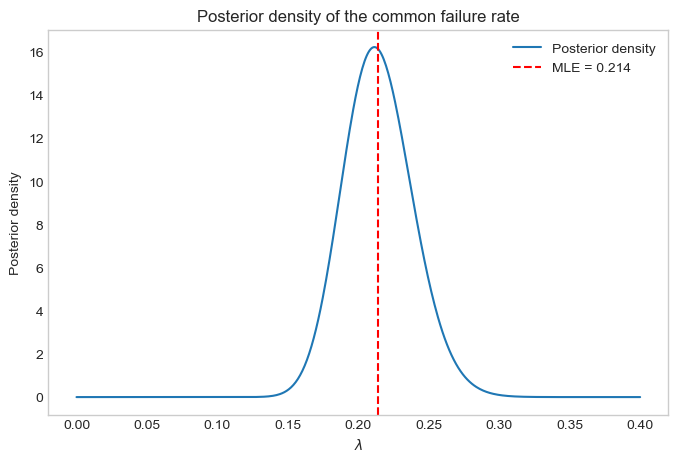

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute MLE ----
a = sum(data['y'])
b = sum(data['t'])
mle = a / b

# ---- Posterior density ----
lambda_vals = np.linspace(1e-6, 0.4, 500)
log_post = deriv.post_density(lambda_vals, log=True)
post = np.exp(log_post)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(lambda_vals, post, label='Posterior density')
plt.axvline(x=mle, color='r', linestyle='--', label=f'MLE = {mle:.3f}')
plt.xlabel(r'$\lambda$')
plt.ylabel('Posterior density')
plt.title('Posterior density of the common failure rate')
plt.legend()
plt.grid()
plt.show()

## 3. Posterior predictive mass

We compute the predictive mass for a new observation at pump 4's exposure (`t_new = 125.76`) and compare with the observed `y=14`.

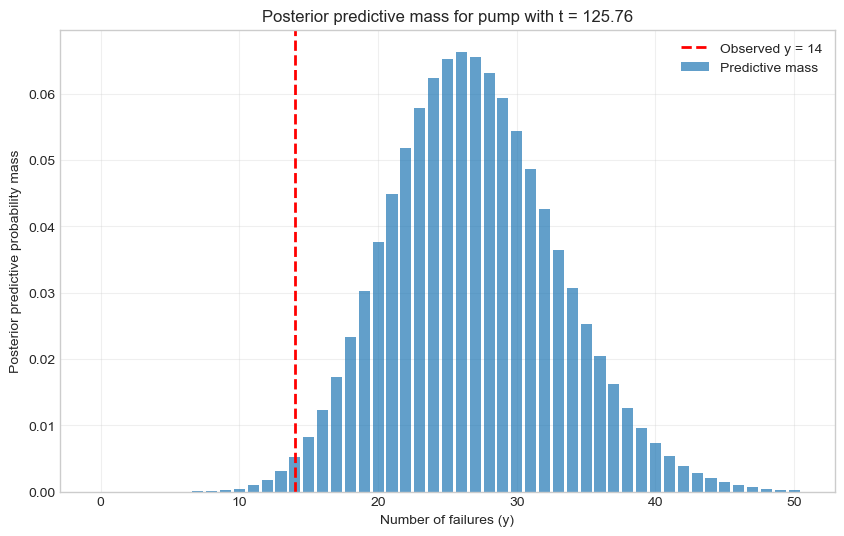

Predictive mass at y=14: 5.246825e-03


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Parameters for pump 4 ----
t_new = 125.76
y_obs = 14

# ---- Compute predictive mass for y = 0..50 ----
y_vals = np.arange(0, 51)
pred_masses = []

for y in y_vals:
    log_pred = deriv.post_predictive(
        pd.DataFrame({'y': [y]}),
        scale=t_new,
        log=True
    )
    pred_masses.append(np.exp(log_pred))

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.bar(y_vals, pred_masses, width=0.8, alpha=0.7, label='Predictive mass')
plt.axvline(x=y_obs, color='r', linestyle='--', linewidth=2, label=f'Observed y = {y_obs}')
plt.xlabel('Number of failures (y)')
plt.ylabel('Posterior predictive probability mass')
plt.title(f'Posterior predictive mass for pump with t = {t_new}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Also print the predictive mass at the observed value ----
log_pred_obs = deriv.post_predictive(
    pd.DataFrame({'y': [y_obs]}),
    scale=t_new,
    log=True
)
print(f"Predictive mass at y={y_obs}: {np.exp(log_pred_obs):.6e}")

## 4. Posterior MGF

The posterior MGF as a function of `r` (for `r < 0`):

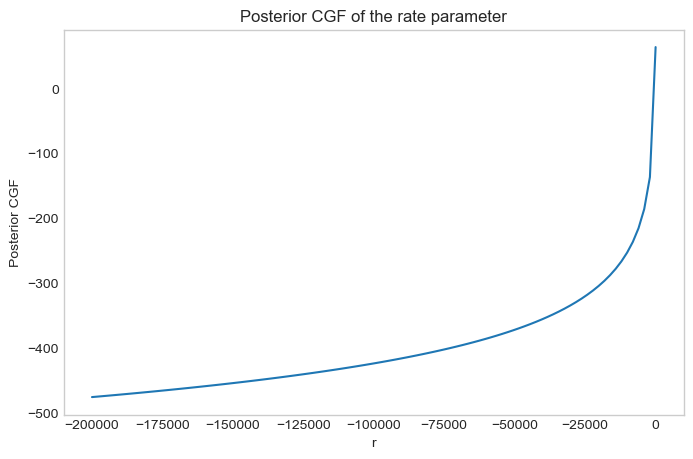

In [8]:
r_vals = np.linspace(-2e5, 200, 100)
cgf_vals = [deriv.post_mgf(r, log=True) for r in r_vals]

plt.figure(figsize=(8,5))
plt.plot(r_vals, cgf_vals)
plt.xlabel('r')
plt.ylabel('Posterior CGF')
plt.title('Posterior CGF of the rate parameter')
plt.grid()
plt.show()

## 5. Posterior moments

We compute the first few moments (mean, variance, etc.) using the `post_moment` method.


In [9]:
for q in [1, 2, 3, 4]:
    moment = deriv.post_moment(q, log=False)
    print(f"E[λ^{q}] = {moment:.6e}")

E[λ^1] = 2.142661e-01
E[λ^2] = 4.652209e-02
E[λ^3] = 1.023392e-02
E[λ^4] = 2.280494e-03


## 6. Sequential updating

We split the data into two chunks: first 5 pumps, then the remaining 5. We update sequentially and compare the final evidence with the full-dataset evidence.

In [10]:
# Split data
data1 = data.iloc[:5]
data2 = data.iloc[5:]

# First chunk
deriv1 = MGFDerivative(
    prior='pareto',
    data=data1['y'],
    likelihood='poisson',
    method='symbolic',
    params=params_pareto,
    scale=data1['t']
)

# Update with second chunk (using jax for speed)
deriv2 = deriv1.update(
    new_data=data2['y'],
    method='jax',
    scale=data2['t']
)

# Sequential log evidence: log evidence of chunk1 + log predictive of chunk2
log_ev_seq = deriv1.evidence()[0] + deriv2.evidence()[0]
print(f"Sequential log evidence: {log_ev_seq:.6f}")
print(f"Full data log evidence: {log_ev:.6f}")
print(f"Difference: {log_ev_seq - log_ev:.2e}")

NameError: name 'params_pareto' is not defined